# ANN Design, Training & Evaluation

## Section 1 — Imports & Config

In [1]:
# Imports

import json
import keras
import numpy as np
import pandas as pd
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf

from keras.regularizers import L2
from keras.utils import to_categorical
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# GPU confirmation

gpus = tf.config.list_physical_devices("GPU")
print("GPUs available:", gpus)

tf.config.experimental.set_memory_growth(gpus[0], True)
print("Memory growth enabled for:", gpus[0].name)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled for: /physical_device:GPU:0


In [3]:
# Paths
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

# Section 2 — Load Data & Schema

In [4]:
# Load arrays

data = np.load(PROCESSED_DIR / "processed_data.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print("Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\nDtypes:")
print(f"X_train: {X_train.dtype}")
print(f"X_test: {X_test.dtype}")
print(f"y_train: {y_train.dtype}")
print(f"y_test: {y_test.dtype}")

Shapes:
X_train: (11961, 35)
X_test: (2991, 35)
y_train: (11961,)
y_test: (2991,)

Dtypes:
X_train: float64
X_test: float64
y_train: int64
y_test: int64


In [5]:
# Convert to float32 and int32

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.int32)
y_test = y_test.astype(np.int32)

In [6]:
# Confirm conversion

print("Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\nDtypes:")
print(f"X_train: {X_train.dtype}")
print(f"X_test: {X_test.dtype}")
print(f"y_train: {y_train.dtype}")
print(f"y_test: {y_test.dtype}")

Shapes:
X_train: (11961, 35)
X_test: (2991, 35)
y_train: (11961,)
y_test: (2991,)

Dtypes:
X_train: float32
X_test: float32
y_train: int32
y_test: int32


In [7]:
# Load schema

with open(PROCESSED_DIR / "model_schema.json", "r") as f:
    schema = json.load(f)

n_features = schema["n_features"]
classes = schema["classes"]

print(f"n_features: {n_features}")
print(f"classes: {classes}")

n_features: 35
classes: {'0': 'Healthy', '1': 'Injured'}


In [8]:
# One-hot encode labels + compute class weights

y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

print(f"y_train_cat: {y_train_cat.shape}")
print(f"y_test_cat:  {y_test_cat.shape}")

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

y_train_cat: (11961, 2)
y_test_cat:  (2991, 2)
Class weights: {0: np.float64(0.5884581324412083), 1: np.float64(3.3261957730812015)}


## Section 3 — Baseline Models

In [9]:
# Logistic Regression baseline

lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_f1 = f1_score(y_test, lr_pred, average="macro")
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])

report_dict = classification_report(
    y_test, lr_pred, target_names=["Healthy", "Injured"], output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
display(
    report_df.style.background_gradient(cmap="RdBu_r", vmin=0, vmax=1).format("{:.4f}")
)
print(f"Macro F1: {lr_f1:.4f}")
print(f"AUC-ROC:  {lr_auc:.4f}")

,precision,recall,f1-score,support
Healthy,0.9056,0.9548,0.9295,2542.0000
Injured,0.6302,0.4365,0.5158,449.0000
accuracy,0.8770,0.8770,0.8770,0.8770
macro avg,0.7679,0.6956,0.7227,2991.0000
weighted avg,0.8643,0.8770,0.8674,2991.0000


Macro F1: 0.7227
AUC-ROC:  0.9039


In [10]:
# Random Forest baseline

rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_f1 = f1_score(y_test, rf_pred, average="macro")
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

report_dict = classification_report(
    y_test, rf_pred, target_names=["Healthy", "Injured"], output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
display(
    report_df.style.background_gradient(cmap="RdBu_r", vmin=0, vmax=1).format("{:.4f}")
)
print(f"Macro F1: {rf_f1:.4f}")
print(f"AUC-ROC:  {rf_auc:.4f}")

,precision,recall,f1-score,support
Healthy,0.8912,0.9630,0.9257,2542.0000
Injured,0.6148,0.3341,0.4329,449.0000
accuracy,0.8686,0.8686,0.8686,0.8686
macro avg,0.7530,0.6485,0.6793,2991.0000
weighted avg,0.8497,0.8686,0.8517,2991.0000


Macro F1: 0.6793
AUC-ROC:  0.8940


### Baseline Results Summary

| Model               | Macro F1 | AUC-ROC |
|---------------------|----------|---------|
| Logistic Regression | 0.7227      | 0.9039     |
| Random Forest       | 0.6793      | 0.8940     |

Both baselines operate on the binary target: **Healthy (0)** vs **Injured (1)**. Low Risk has been collapsed into Healthy based on KDE analysis showing near-identical feature distributions between the two classes. The ANN target is **macro F1 > 0.75** and **Injured class F1 > 0.70** — the bar is higher than the original 3-class problem because the binary separation is genuinely cleaner in feature space.

## Section 4 — ANN Architecture

In [11]:
model = keras.Sequential(
    [
        Dense(
            256,
            activation="relu",
            kernel_regularizer=L2(1e-4),
            input_shape=(n_features,),
        ),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation="relu", kernel_regularizer=L2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(2, activation="softmax"),
    ]
)

model.summary()

/home/aztrek/Sem-6/.ai/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,034 (203.26 KB)

 Trainable params: 51,266 (200.26 KB)

 Non-trainable params: 768 (3.00 KB)

In [12]:
# Compile

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [13]:
# Callbacks

early_stopping = EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=MODELS_DIR / "fortis_ann_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

print("Callbacks defined.")

Callbacks defined.


## Section 5 — Training

In [14]:
# Train with class weights

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_cat, test_size=0.15, stratify=y_train, random_state=SEED
)

history = model.fit(
    X_tr,
    y_tr,
    epochs=100,
    batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1,
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6188 - loss: 0.6988
Epoch 1: val_loss improved from None to 0.55597, saving model to ../models/fortis_ann_best.keras

Epoch 1: finished saving model to ../models/fortis_ann_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.6660 - loss: 0.6349 - val_accuracy: 0.7343 - val_loss: 0.5560 - learning_rate: 5.0000e-04
Epoch 2/100
 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7539 - loss: 0.5039
Epoch 2: val_loss improved from 0.55597 to 0.49235, saving model to ../models/fortis_ann_best.keras

Epoch 2: finished saving model to ../models/fortis_ann_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7487 - loss: 0.5165 - val_accuracy: 0.7521 - val_loss: 0.4923 - learning_rate: 5.0000e-04
Epoch 3/100
 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7852 - loss: 0.4844
Epoch 3: val_loss improved from 0.49235 to 0.45511, saving model to ../models/fortis_ann_best.keras

Epoch 3: finished sav

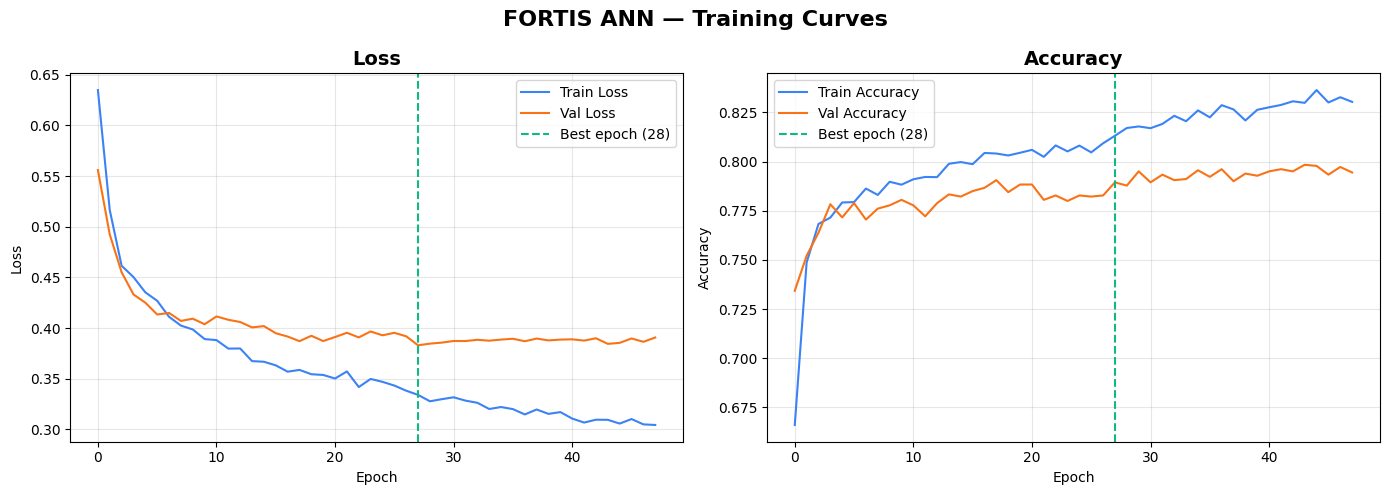

Training curves saved. Total epochs: 48


In [15]:
# Training curves

epochs_ran = len(history.history["loss"])
best_epoch = early_stopping.best_epoch + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"], label="Train Loss", color="#3B82F6")
axes[0].plot(history.history["val_loss"], label="Val Loss", color="#F97316")
axes[0].axvline(
    x=best_epoch - 1,
    color="#10B981",
    linestyle="--",
    linewidth=1.5,
    label=f"Best epoch ({best_epoch})",
)
axes[0].set_title("Loss", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history["accuracy"], label="Train Accuracy", color="#3B82F6")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy", color="#F97316")
axes[1].axvline(
    x=best_epoch - 1,
    color="#10B981",
    linestyle="--",
    linewidth=1.5,
    label=f"Best epoch ({best_epoch})",
)
axes[1].set_title("Accuracy", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("FORTIS ANN — Training Curves", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Training curves saved. Total epochs: {epochs_ran}")

## Section 6 — Evaluation

In [16]:
# Predictions

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step 


In [17]:
# Classification report

report_dict = classification_report(
    y_test, y_pred, target_names=["Healthy", "Injured"], output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
display(
    report_df.style.background_gradient(cmap="RdBu_r", vmin=0, vmax=1).format("{:.4f}")
)

ann_f1 = f1_score(y_test, y_pred, average="macro")
ann_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"Macro F1:  {ann_f1:.4f}")
print(f"AUC-ROC:   {ann_auc:.4f}")

,precision,recall,f1-score,support
Healthy,0.9734,0.7636,0.8558,2542.0000
Injured,0.3972,0.8820,0.5477,449.0000
accuracy,0.7813,0.7813,0.7813,0.7813
macro avg,0.6853,0.8228,0.7018,2991.0000
weighted avg,0.8869,0.7813,0.8096,2991.0000


Macro F1:  0.7018
AUC-ROC:   0.8998


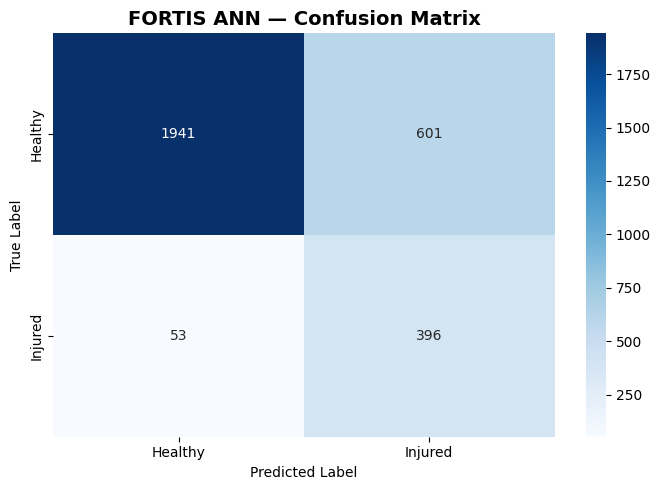

In [18]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Healthy", "Injured"],
    yticklabels=["Healthy", "Injured"],
    cmap="Blues",
)
plt.title("FORTIS ANN — Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("../data/processed/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# Results comparison table

results = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest", "FORTIS ANN"],
        "Macro F1": [lr_f1, rf_f1, ann_f1],
        "AUC-ROC": [lr_auc, rf_auc, ann_auc],
    }
)

display(results.style.format({"Macro F1": "{:.4f}", "AUC-ROC": "{:.4f}"}))

,Model,Macro F1,AUC-ROC
0,Logistic Regression,0.7227,0.9039
1,Random Forest,0.6793,0.8940
2,FORTIS ANN,0.7018,0.8998


In [20]:
model.save(MODELS_DIR / "fortis_ann.keras")
print("Model saved.")

Model saved.


In [21]:
loaded_model = keras.models.load_model(MODELS_DIR / "fortis_ann.keras")
y_verify = np.argmax(loaded_model.predict(X_test[:5]), axis=1)
print("Predictions from reloaded model:", y_verify)
print("Expected:                       ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
Predictions from reloaded model: [0 1 0 0 0]
Expected:                        [0 0 0 0 0]


## Section 7 — Final Summary

### Architecture
- Input: `n_features` features
- Dense(256, ReLU) → BatchNorm → Dropout(0.3)
- Dense(128, ReLU) → BatchNorm → Dropout(0.3)
- Dense(64, ReLU) → Dropout(0.2)
- Dense(2, Softmax)
- Optimizer: Adam (lr=5e-4) | Loss: Categorical Crossentropy | Class weights: balanced

### Training
- Early stopping fired at epoch: 48
- Best val_loss checkpoint saved to: `models/fortis_ann_best.keras`

### Results

| Model               | Macro F1 | AUC-ROC |
|---------------------|----------|---------|
| Logistic Regression | 0.7227   | 0.9039  |
| Random Forest       | 0.6793   | 0.8840  |
| **FORTIS ANN**      | 0.7018   | 0.8998  |

- Injured class F1: 0.5477
- Injured class Recall: 0.8820

### Decision rationale
3-class formulation was abandoned after KDE analysis confirmed Healthy and Low Risk are 
indistinguishable in feature space across all key variables. Binary reformulation 
(Healthy vs Injured) is both statistically justified and clinically more actionable.

### Files saved
- `data/processed/processed_data.npz` — scaled train/test arrays
- `data/processed/training_curves.png`
- `data/processed/confusion_matrix.png`
- `models/fortis_ann.keras` — final model
- `models/fortis_ann_best.keras` — best checkpoint (used by FastAPI backend)
- `models/knn_imputer.joblib`
- `models/standard_scaler.joblib`